# Virtual Fleet for under-ice positionning
## use case

In [17]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import timedelta
import sys
import itertools
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
land_feature=cfeature.NaturalEarthFeature(category='physical',name='land',scale='50m',facecolor=[0.4,0.6,0.7])
pr1=ccrs.PlateCarree()
from glob import glob
sys.path.insert(0, "..") # This is when you load VirtualFleet functions
from virtualargofleet import Velocity, FloatConfiguration, VirtualFleet
from parcels import FieldSet, Field
sys.path.insert(0, "/home/kbalem/Bureau/argopy")

import cartopy.geodesic as geodesic
Geodesic = geodesic.Geodesic()

## Use argopy to retrieve positions of float 7900931

In [2]:
from argopy import ArgoIndex
idx = ArgoIndex(index_file='core')
idx.query.wmo(7900931)
df = idx.to_dataframe(index=False)
df

/tmp/ipykernel_65439/2426792183.py:4: FutureWarning: Note that the long name for institution is now in 'institution_name' while the 'institution' column will hold the institution code -- Deprecated since version 1.4
  df = idx.to_dataframe(index=False)


,file,date,latitude,longitude,ocean,profiler_code,institution,date_update,wmo,cyc,institution_name,dac,profiler
0,csiro/7900931/profiles/D7900931_001.nc,2022-02-15 12:39:44,-74.856,172.494,P,846,CS,2025-09-10 06:37:32,7900931,1,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
1,csiro/7900931/profiles/D7900931_002.nc,2022-02-19 23:07:50,-74.827,172.565,P,846,CS,2025-09-10 06:37:32,7900931,2,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
2,csiro/7900931/profiles/D7900931_003.nc,2022-02-24 09:16:58,-74.824,172.569,P,846,CS,2025-09-10 06:37:32,7900931,3,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
3,csiro/7900931/profiles/D7900931_004.nc,2022-02-28 19:25:57,-74.787,172.583,P,846,CS,2025-09-10 06:37:32,7900931,4,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
4,csiro/7900931/profiles/D7900931_005.nc,2022-03-05 12:20:01,-74.681,172.775,P,846,CS,2025-09-10 06:37:32,7900931,5,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,csiro/7900931/profiles/R7900931_316.nc,2026-05-15 08:20:45,-63.326,142.638,I,846,CS,2026-05-15 10:38:52,7900931,316,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
316,csiro/7900931/profiles/R7900931_317.nc,2026-05-25 10:51:16,-63.601,142.271,I,846,CS,2026-05-25 13:38:15,7900931,317,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
317,csiro/7900931/profiles/R7900931_318.nc,2026-06-04 13:22:15,-63.757,142.436,I,846,CS,2026-06-04 15:34:32,7900931,318,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...
318,csiro/7900931/profiles/R7900931_319.nc,2026-06-14 16:07:46,-64.038,143.610,I,846,CS,2026-06-14 18:35:27,7900931,319,"CSIRO, Australia",csiro,Teledyne Webb Research float with SBE conducti...


# Let's try to position cycles 242 to 300

In [3]:
S = df.iloc[242][['longitude','latitude','date']].values
E = df.iloc[300][['longitude','latitude','date']].values

## Let's use a dask client to speed up the virtual fleet simulation

In [4]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 20,Total memory: 30.99 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41897,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42971,Total threads: 4
Dashboard: http://127.0.0.1:42205/status,Memory: 6.20 GiB
Nanny: tcp://127.0.0.1:46211,


## We use glory monthly climatology, let's open one file to check

In [5]:
files = glob('/home/kbalem/Bureau/glorys_clim/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_202311/*.nc')
files.sort()
print(files[0],'\n to \n',files[-1])
ds = xr.open_dataset(files[0])
ds

/home/kbalem/Bureau/glorys_clim/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_202311/mercatorglorys12v1_gl12_mean_1993_2016_01.nc 
 to 
 /home/kbalem/Bureau/glorys_clim/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_202311/mercatorglorys12v1_gl12_mean_1993_2016_12.nc


<xarray.Dataset> Size: 7GB
Dimensions:             (time: 1, nv: 2, latitude: 2041, longitude: 4320,
                         depth: 50)
Coordinates:
  * time                (time) datetime64[ns] 8B 2004-01-15
  * latitude            (latitude) float32 8kB -80.0 -79.92 ... 89.92 90.0
  * longitude           (longitude) float32 17kB -180.0 -179.9 ... 179.8 179.9
  * depth               (depth) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
Dimensions without coordinates: nv
Data variables:
    climatology_bounds  (time, nv) datetime64[ns] 16B ...
    mlotst              (time, latitude, longitude) float32 35MB ...
    zos                 (time, latitude, longitude) float32 35MB ...
    bottomT             (time, latitude, longitude) float32 35MB ...
    sithick             (time, latitude, longitude) float32 35MB ...
    siconc              (time, latitude, longitude) float32 35MB ...
    usi                 (time, latitude, longitude) float32 35MB ...
    vsi                 (time, latitude, longitude) float32 35MB ...
    thetao              (time, depth, latitude, longitude) float32 2GB ...
    so                  (time, depth, latitude, longitude) float32 2GB ...
    uo                  (time, depth, latitude, longitude) float32 2GB ...
    vo                  (time, depth, latitude, longitude) float32 2GB ...
Attributes: (12/17)
    CDI:                           Climate Data Interface version 1.9.3 (http...
    source:                        MERCATOR GLORYS12V1
    institution:                   Mercator Ocean
    Conventions:                   CF-1.6
    references:                    http://marine.copernicus.eu
    credit:                        E.U. Copernicus Marine Service Information...
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    CDO:                           Climate Data Operators version 1.9.3 (http...
    title:                         Monthly climatology fields for product GLO...
    dataset:                       global-reanalysis-phy-001-030-monthly-clim...
    field_type:                    monthly_climatology

## Let's configurate parcel fieldset for VF

In [ ]:
root = "/home/kbalem/Bureau/glorys_clim/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_202311"
filenames = {'U': root + "/*.nc",
              'V': root + "/*.nc"}
variables = {'U':'uo', 'V':'vo'}
dimensions = {'time': 'time', 'depth':'depth', 'lat': 'latitude', 'lon': 'longitude'}
fieldset = FieldSet.from_netcdf(filenames, variables, dimensions,time_periodic=timedelta(days=365),chunksize='auto')

## Add the bathy mask

In [7]:
# BATHY 
dst = ds.isel(time=0)
dst['mk'] = (~dst['uo'].isnull()).astype(int)
ix = (dst['mk'].cumsum('depth').max('depth') - 1)
mask = (dst['depth'][ix] - 50).transpose('longitude', 'latitude')
mask = mask.values
mask[mask<0] = 0
fieldset.add_field(Field('bathy',data=mask, lon=ds['longitude'].values,lat=ds['latitude'].values,transpose=True,mesh='spherical',interp_method='nearest'))

## Display velocity field to see if parcels part is ok

In [161]:
fieldset.computeTimeChunk(fieldset.U.grid.time[0], 1.)

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:342: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.

np.float64(2678400.0)

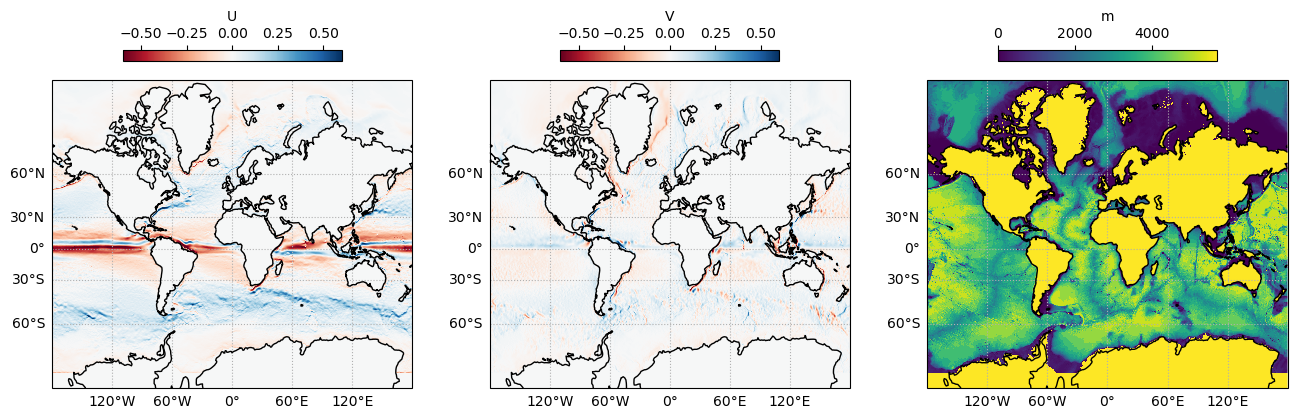

In [162]:
fig=plt.figure(figsize=(16,5))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 3, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.U.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='U')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 2, projection=pr2)
a=ax1.pcolormesh(fieldset.V.grid.lon,fieldset.V.grid.lat,fieldset.V.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='V')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 3, projection=pr2)
a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0)
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
plt.colorbar(a,location='top',shrink=0.6,label='m')

## Let's configurate Float configuration & deployment plan

In [8]:
mission = FloatConfiguration('default')
#mission.update('parking_depth', 1000)
#mission.update('profile_depth', 2000)
mission.update('cycle_duration', 24*4.5)
mission

<FloatConfiguration><default>
- cycle_duration (Maximum length of float complete cycle): 108.0 [hours]
- life_expectancy (Maximum number of completed cycle): 200 [cycle]
- parking_depth (Drifting depth): 1000.0 [m]
- profile_depth (Maximum profile depth): 2000.0 [m]
- vertical_speed (Vertical profiling speed): 0.09 [m/s]

In [9]:
Starting_point = [S[0], S[1]]
Starting_time = np.datetime64(S[2])
Ending_point = [E[0], E[1]]
Ending_time = np.datetime64(E[2])
duration = (Ending_time - Starting_time).astype('timedelta64[s]')
duration = timedelta(seconds=int(duration.astype(int)))
duration

datetime.timedelta(days=270, seconds=6302)

In [10]:
lon0, lat0 = Starting_point[0], Starting_point[1]  # Center of the box

Lx, Ly = 1.0, 1.0 # Size of the box
fbox = [lon0-Lx/2,lat0-Ly/2,lon0+Lx/2,lat0+Ly/2]
coords=np.array(list(itertools.product(np.arange(fbox[0],fbox[2],.1),np.arange(fbox[1],fbox[3],.1))))
lon = coords[:,0]
lat = coords[:,1]
nfloats=len(lon)
#dpt = np.linspace(min_depth, min_depth, nfloats) #1m depth
tim = np.array([Starting_time for i in range(nfloats)],dtype='datetime64')
my_plan = {'lat': lat, 
           'lon': lon, 
           'time': tim}

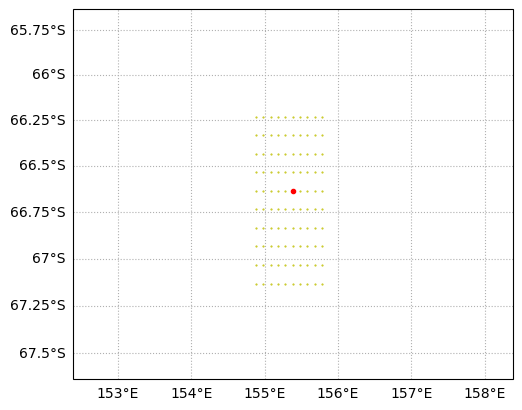

In [167]:
fig=plt.figure()
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 1, 1, projection=pr2)
#a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0)
#b=ax1.contourf(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:,:],np.arange(990,1010),transform=pr1)
ax1.coastlines(resolution='10m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(my_plan['lon'],my_plan['lat'],'y.',markersize=1,transform=pr1)
ax1.set_extent([lon0-3,lon0+3,lat0-1,lat0+1])
ax1.plot(lon0,lat0,'r.',transform=pr1)

## Instantiate VF object & simulate

In [11]:
VFleet = VirtualFleet(plan=my_plan, fieldset=fieldset, mission=mission, verbose_events=False)
VFleet

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particleset.py:178: ParticleSetWarning: Some particles are set to be released after the fieldset's last time and allow_time_extrapolation is set to False.
  _warn_particle_times_outside_fieldset_time_bounds(time, fieldset.U.grid.time_full)


<VirtualFleet>
- 100 floats in the deployment plan
- No simulation performed

In [12]:
VFleet.simulate(
    duration=duration,
    step=timedelta(minutes=5),
    record=timedelta(hours=24),
    output_file="under_ice_test_9.zarr",
    output_folder="data"
)

/home/kbalem/Bureau/VirtualFleet/knotebooks/../virtualargofleet/virtualargofleet.py:361: UserWarning: Simulation will be saved in : data/under_ice_test_9.zarr
  warnings.warn(output_msg)


INFO: Output files are stored in data/under_ice_test_9.zarr.
  0%|                                           | 0/23334302.0 [00:00<?, ?it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:342: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.

  0%|                           | 300.0/23334302.0 [00:19<418:54:00, 15.47it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


...

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:342: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:792: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 4096. This could degrade performance. Instead, consider rechunking after loading.
  self.dataset = xr.open_dataset(
/home/kbalem/miniforge3/envs/x26K/lib/python3.

 98%|███████████████████████▋| 22982400.0/23334302.0 [10:22<01:02, 5664.39it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|███████████████████████| 23334302.0/23334302.0 [11:01<00:00, 35294.85it/s]


<VirtualFleet>
- 100 floats in the deployment plan
- Number of simulation(s): 1
- Last simulation meta-data:
	- Duration: 270d 01h 45m 02s
	- Data recording every: 24h 00m
	- Trajectory file: data/under_ice_test_9.zarr
	- Execution time: 00d 00h 11m 04s
	- Executed on: L-BR-LOPS-P26

In [15]:
client.close()

## Open result file and plot trajectories

In [13]:
ds = xr.open_zarr('data/under_ice_test_9.zarr')
ds.load()

<xarray.Dataset> Size: 1MB
Dimensions:       (trajectory: 100, obs: 271)
Coordinates:
  * trajectory    (trajectory) int64 800B 100 101 102 103 ... 196 197 198 199
  * obs           (obs) int32 1kB 0 1 2 3 4 5 6 ... 264 265 266 267 268 269 270
Data variables:
    cycle_age     (trajectory, obs) float32 108kB 900.0 8.79e+04 ... 6e+03
    cycle_number  (trajectory, obs) float64 217kB 1.0 1.0 1.0 ... 60.0 60.0 61.0
    cycle_phase   (trajectory, obs) float64 217kB 0.0 1.0 1.0 ... 1.0 1.0 0.0
    lat           (trajectory, obs) float32 108kB -67.13 -67.14 ... -64.84
    lon           (trajectory, obs) float32 108kB 154.9 154.9 ... 160.0 160.0
    time          (trajectory, obs) datetime64[ns] 217kB 2025-03-19T09:18:27 ...
    z             (trajectory, obs) float32 108kB 1.0 815.0 ... 1e+03 514.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

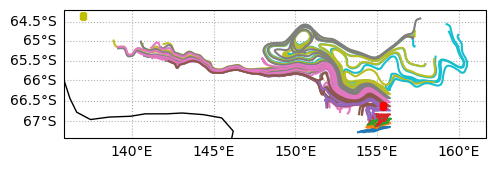

In [14]:
fig=plt.figure(figsize=(12,12))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
#a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0,cmap=plt.get_cmap('viridis_r'))
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
for t in range(len(ds.trajectory.values)):
    #ax1.plot(ds['lon'].isel(obs=0,trajectory=t),ds['lat'].isel(obs=0,trajectory=t),'*',markeredgecolor='k',transform=pr1,zorder=10)
    ax1.plot(ds['lon'].isel(trajectory=t),ds['lat'].isel(trajectory=t),transform=pr1)
    #ax1.plot(ds['lon'].isel(trajectory=t, obs=-1),ds['lat'].isel(trajectory=t, obs=-1),'s',markeredgecolor='k',transform=pr1)
#ax1.set_extent([np.min([ds['lon'].min(),E[0]])-2,np.max([ds['lon'].max(),E[0]])+2,np.min([ds['lat'].min(),E[1]])-2,np.max([ds['lat'].max(),E[1]])+4],crs=pr1)
ax1.plot(Starting_point[0],Starting_point[1],'rs',markersize=5,transform=pr1)
ax1.plot(Ending_point[0],Ending_point[1],'ys',markersize=5,transform=pr1)


## Let's find the trajectories with the closest endpoint to the expected one

In [41]:
# find trajectory with closest endpoint
dend = ds.isel(obs=-1)
inv = Geodesic.inverse([Ending_point[0],Ending_point[1]],np.vstack([dend['lon'],dend['lat']]).transpose())
ix = inv[:,0].argsort()[:3]
ix

array([ 8, 76, 37])

In [46]:
dmean = ds.isel(trajectory=8).sortby('time')

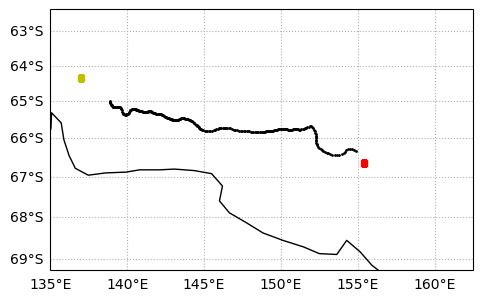

In [47]:
fig=plt.figure(figsize=(12,12))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
#a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0,cmap=plt.get_cmap('viridis_r'))
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(dmean['lon'],dmean['lat'],'ok',markersize=1,transform=pr1)
#plt.colorbar(a,location='top',shrink=0.6,label='Z')
ax1.set_extent([np.min([ds['lon'].min(),E[0]])-2,np.max([ds['lon'].max(),E[0]])+2,np.min([ds['lat'].min(),E[1]])-2,np.max([ds['lat'].max(),E[1]])+2],crs=pr1)
ax1.plot(Starting_point[0],Starting_point[1],'rs',markersize=5,transform=pr1)
ax1.plot(Ending_point[0],Ending_point[1],'ys',markersize=5,transform=pr1)


# CORRECT, SCALE & ROTATE THE TRAJECTORY

In [70]:
# Recal sim traj on real start
inv0 = Geodesic.inverse([dmean['lon'][0],dmean['lat'][0]],Starting_point)
dist0 = inv0[0][0]
azim0 = inv0[0][1]
new_lons0 = np.zeros(len(dmean.obs))
new_lats0 = np.zeros(len(dmean.obs))
for i in range(len(dmean.obs)):
    direct0 = Geodesic.direct([dmean['lon'][i],dmean['lat'][i]],azim0-np.pi, dist0)
    new_lons0[i] = direct0[0][0]
    new_lats0[i] = direct0[0][1]

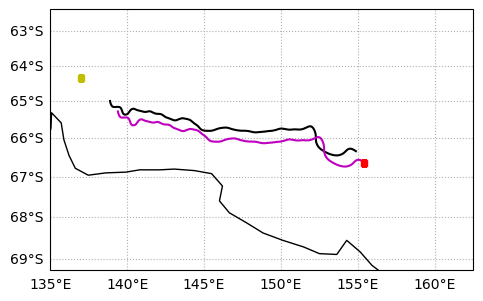

In [71]:
fig=plt.figure(figsize=(12,12))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(dmean['lon'],dmean['lat'],'k',markersize=1,transform=pr1)
ax1.plot(new_lons0,new_lats0,'m',transform=pr1)
ax1.set_extent([np.min([ds['lon'].min(),E[0]])-2,np.max([ds['lon'].max(),E[0]])+2,np.min([ds['lat'].min(),E[1]])-2,np.max([ds['lat'].max(),E[1]])+2],crs=pr1)
ax1.plot(Starting_point[0],Starting_point[1],'rs',markersize=5,transform=pr1)
ax1.plot(Ending_point[0],Ending_point[1],'ys',markersize=5,transform=pr1)

In [72]:
# calculate scale & bearing to apply between start point & sim target & real target
invE = Geodesic.inverse(Starting_point,[new_lons0[-1],new_lats0[-1]])
distE = invE[0][0]
azimE = invE[0][1]
invT = Geodesic.inverse(Starting_point,Ending_point)
distT = invT[0][0]
azimT = invT[0][1]
scaleET = distT / distE
rotationET = azimT - azimE

In [74]:
# apply to each point relatively to start point
new_lons = np.zeros(len(dmean.obs))
new_lats = np.zeros(len(dmean.obs))
lz = len(dmean.obs)
for i in range(lz):
    # Relative to start
    inverse = Geodesic.inverse(Starting_point,[new_lons0[i],new_lats0[i]])
    dist1 = inverse[0][0]
    bear1 = inverse[0][1]    
    # End Rotate & Scale
    new_distance = scaleET * dist1
    new_azimuth  = bear1 + rotationET
    direct = Geodesic.direct([new_lons0[0],new_lats0[0]],new_azimuth, new_distance)
    new_lons[i] = direct[0][0]
    new_lats[i] = direct[0][1]

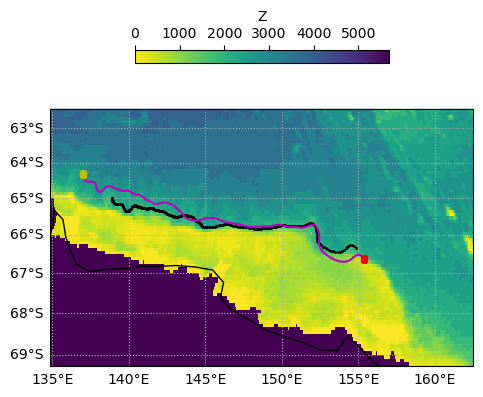

In [75]:
fig=plt.figure(figsize=(12,12))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,vmin=0,cmap=plt.get_cmap('viridis_r'))
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(dmean['lon'],dmean['lat'],'ok',markersize=1,transform=pr1)
ax1.plot(new_lons,new_lats,'m',transform=pr1)
plt.colorbar(a,location='top',shrink=0.6,label='Z')
ax1.set_extent([ds['lon'].min()-4,ds['lon'].max()+2,ds['lat'].min()-2,ds['lat'].max()+2],crs=pr1)
ax1.plot(Starting_point[0],Starting_point[1],'rs',markersize=5,transform=pr1)
ax1.plot(Ending_point[0],Ending_point[1],'ys',markersize=5,transform=pr1)

## interpolate lon,lat to profiles timestamp

In [82]:
dmean_i = dmean.copy()
dmean_i['lon'].values = new_lons
dmean_i['lat'].values = new_lats
dmean_i

<xarray.Dataset> Size: 14kB
Dimensions:       (obs: 271)
Coordinates:
  * obs           (obs) int32 1kB 0 1 2 3 4 5 6 ... 264 265 266 267 268 269 270
    trajectory    int64 8B 108
Data variables:
    cycle_age     (obs) float32 1kB 900.0 8.79e+04 ... 3.06e+05 4.2e+03
    cycle_number  (obs) float64 2kB 1.0 1.0 1.0 1.0 1.0 ... 60.0 60.0 60.0 61.0
    cycle_phase   (obs) float64 2kB 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    lat           (obs) float64 2kB -66.61 -66.56 -66.53 ... -64.34 -64.32
    lon           (obs) float64 2kB 155.5 155.3 155.2 ... 137.1 137.0 137.0
    time          (obs) datetime64[ns] 2kB 2025-03-19T09:18:27 ... 2025-12-14...
    z             (obs) float32 1kB 1.0 1e+03 1e+03 1e+03 ... 1e+03 1e+03 352.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [84]:
# Set time as a coordinate
dmean_i = dmean_i.set_coords('time')
dmean_i = dmean_i.swap_dims({'obs':'time'})
dmean_i

<xarray.Dataset> Size: 14kB
Dimensions:       (time: 271)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2025-03-19T09:18:27 ... 2025-12-1...
    obs           (time) int32 1kB 0 1 2 3 4 5 6 ... 264 265 266 267 268 269 270
    trajectory    int64 8B 108
Data variables:
    cycle_age     (time) float32 1kB 900.0 8.79e+04 ... 3.06e+05 4.2e+03
    cycle_number  (time) float64 2kB 1.0 1.0 1.0 1.0 1.0 ... 60.0 60.0 60.0 61.0
    cycle_phase   (time) float64 2kB 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    lat           (time) float64 2kB -66.61 -66.56 -66.53 ... -64.34 -64.32
    lon           (time) float64 2kB 155.5 155.3 155.2 ... 137.1 137.0 137.0
    z             (time) float32 1kB 1.0 1e+03 1e+03 1e+03 ... 1e+03 1e+03 352.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [86]:
# interp at profiles datetime
posits = df.iloc[242:300]
posits_time = posits['date'].values
posits_time

array(['2025-03-19T09:18:27', '2025-03-23T19:39:48',
       '2025-03-28T12:50:03', '2025-04-02T05:16:17',
       '2025-04-06T20:17:30', '2025-04-11T10:51:59',
       '2025-04-16T02:02:07', '2025-04-20T18:01:04',
       '2025-04-25T09:49:54', '2025-04-30T00:37:41',
       '2025-05-04T15:02:32', '2025-05-09T05:28:19',
       '2025-05-13T19:25:01', '2025-05-18T10:20:07',
       '2025-05-23T01:16:48', '2025-05-27T15:38:44',
       '2025-06-01T08:42:26', '2025-06-05T23:03:10',
       '2025-06-10T16:00:42', '2025-06-15T09:08:44',
       '2025-06-20T02:15:50', '2025-06-24T19:34:46',
       '2025-06-29T12:32:26', '2025-07-04T04:59:15',
       '2025-07-08T20:47:43', '2025-07-13T11:27:55',
       '2025-07-18T04:12:54', '2025-07-22T14:45:37',
       '2025-07-27T07:27:22', '2025-07-31T19:47:39',
       '2025-08-05T08:45:49', '2025-08-09T21:52:25',
       '2025-08-14T11:14:26', '2025-08-19T00:35:50',
       '2025-08-23T13:32:56', '2025-08-28T02:45:22',
       '2025-09-01T16:48:19', '2025-09-06T07:3

In [91]:
final_positions = dmean_i[['lon','lat']].interp(time=posits_time)
final_positions

<xarray.Dataset> Size: 2kB
Dimensions:     (time: 58)
Coordinates:
  * time        (time) datetime64[s] 464B 2025-03-19T09:18:27 ... 2025-12-09T...
    obs         (time) float64 464B 0.0 4.431 9.147 13.83 ... 255.6 260.3 265.1
    trajectory  int64 8B 108
Data variables:
    lon         (time) float64 464B 155.5 154.8 154.1 ... 137.6 137.3 137.1
    lat         (time) float64 464B -66.61 -66.55 -66.7 ... -64.54 -64.53 -64.45
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

# TADAAAAA

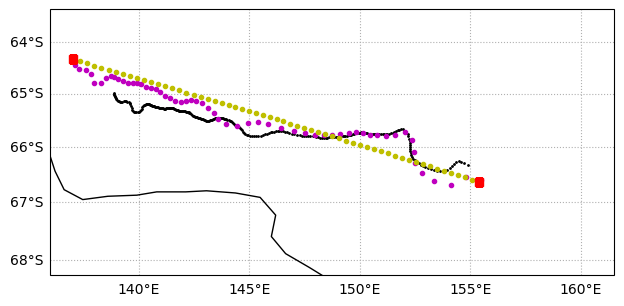

In [98]:
fig=plt.figure(figsize=(16,16))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 2, 1, projection=pr2)
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(dmean['lon'],dmean['lat'],'ok',markersize=1,transform=pr1)
ax1.plot(final_positions['lon'],final_positions['lat'],'.m',transform=pr1)
ax1.plot(posits['longitude'],posits['latitude'],'.y',transform=pr1)

ax1.set_extent([np.min([ds['lon'].min(),E[0]])-1,np.max([ds['lon'].max(),E[0]])+1,np.min([ds['lat'].min(),E[1]])-1,np.max([ds['lat'].max(),E[1]])+1],crs=pr1)

ax1.plot(Starting_point[0],Starting_point[1],'rs',markersize=6,transform=pr1)
ax1.plot(Ending_point[0],Ending_point[1],'rs',markersize=6,transform=pr1)